# Week 9 Phase 1.13 — Fixed Physics Mean + ARD GP Discrepancy

This teaching notebook reads generated artifacts and does not rerun the 13,000 main GP fits.

## 1. Why this phase exists

Phase 1.11 found no resolved gain from an isotropic discrepancy. Phase 1.12 then showed that ARD materially improved the standalone 4D GPC. H was strongest at B16, while standalone G3 became stronger later. M3 asks whether one model can combine these behaviors.

In [1]:
from pathlib import Path
import json, pandas as pd
from IPython.display import display, Image, Markdown
ROOT=Path.cwd().parents[1] if Path.cwd().name=='week_09' else Path.cwd()
OUT=ROOT/'outputs'/'week9_phase1_13_fixed_physics_ard_discrepancy'
display(json.loads((OUT/'baseline_gate.json').read_text()))

{'A0_paths': 100,
 'G0_q20_AULC': 0.8135202205882353,
 'G3_q20_AULC': 0.826594669117647,
 'H_q20_AULC': 0.8308134191176471,
 'M2_q20_AULC': 0.8302297794117648,
 'budgets': [16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70,
  71,
  72,
  73,
  74,
  75,
  76,
  77,
  78,
  79,
  80],
 'conduction': 332,
 'current_head': '161453983996b763824f2d262b5ce9d63332da16',
 'folds_per_repeat': 5,
 'initial_design_matches': 100,
 'keyholes': 73,
 'outer_runs': 100,
 'phase112_is_ancestor': True,
 'phase112_placeholder_absent': True,
 'phase112_sha': '161453983996b763824f2d262b5ce9d63332da16',
 'population': 405,
 'repeat_blocks': 20,
 'status': 'PASS'}

## 2. Architecture and the M2W control

Stage 1 fits `m_h=b0+b_h z(log h)` from revealed labels and freezes it. Stage 2 fits `r(x)` on standardized P,VX,LS,ST. M2W and M3 have identical wide bounds; M2W has one lengthscale and M3 has four. Thus M3-M2W isolates anisotropy.

In [2]:
display(pd.DataFrame(json.loads((OUT/'kernel_specification.json').read_text())['models']).T)

,ard,kernel,role
M2W,False,"0.3**2 * Matern(length_scale=1, nu=1.5)",mechanistic_bound-matched_control
M3,True,"0.3**2 * Matern(length_scale=[1, 1, 1, 1], nu=...",primary_new_model
M3_L1000,True,"0.3**2 * Matern(length_scale=[1, 1, 1, 1], nu=...",fixed-path checkpoint sensitivity only


## 3. ARD implementation parity

The custom zero-mean Laplace classifier must match sklearn under identical fixed ARD parameters before science.

In [3]:
display(json.loads((OUT/'ard_parity_report.json').read_text()))

{'cases': [{'case': 'toy_4d',
   'max_absolute_probability_difference': 0.0,
   'mean_absolute_probability_difference': 0.0,
   'rows': 25},
  {'case': 'w85__r01_f01_B16',
   'max_absolute_probability_difference': 0.0,
   'mean_absolute_probability_difference': 0.0,
   'rows': 81},
  {'case': 'w85__r10_f05_B40',
   'max_absolute_probability_difference': 0.0,
   'mean_absolute_probability_difference': 0.0,
   'rows': 81},
  {'case': 'w85__r20_f05_B80',
   'max_absolute_probability_difference': 0.0,
   'mean_absolute_probability_difference': 0.0,
   'rows': 81}],
 'fixed_ARD_parameters': {'lengthscales': [0.8, 1.1, 1.4, 1.8],
  'nu': 1.5,
  'variance': 0.27},
 'maximum_probability_difference': 0.0,
 'reference': 'sklearn GaussianProcessClassifier, identical fixed ARD kernel, zero mean',
 'status': 'PASS',
 'tolerance': 1e-05}

## 4. Main q20 result on the frozen A0 path

,model,subset,mean_AULC,ci_lower,ci_upper,role
0,G0,B1_q20,0.813520,0.806806,0.820492,headline
1,G0,B1_q30,0.866116,0.861500,0.870688,headline
2,G3,B1_q20,0.826595,0.818828,0.834288,headline
3,G3,B1_q30,0.869675,0.862041,0.876466,headline
4,H,B1_q20,0.830813,0.826806,0.835000,headline
5,H,B1_q30,0.871597,0.868762,0.874460,headline
6,M2,B1_q20,0.830230,0.826769,0.833713,headline
7,M2,B1_q30,0.871712,0.868797,0.874684,headline
8,M3,B1_q20,0.842491,0.838438,0.846746,headline
9,M3,B1_q30,0.883847,0.880341,0.887141,headline


,contrast,subset,mean_difference,ci_lower,ci_upper,positive_repeat_blocks,zero_repeat_blocks,negative_repeat_blocks,bootstrap_draws,predeclared_role
0,M3-H,B1_q20,0.011677,0.007201,0.016149,18,0,2,10000,primary
1,M3-M2,B1_q20,0.012261,0.007638,0.016705,18,0,2,10000,secondary
2,M3-M2W,B1_q20,0.012261,0.007624,0.016609,18,0,2,10000,mechanistic
3,M3-G3,B1_q20,0.015896,0.008051,0.024219,15,0,5,10000,secondary
4,M3-G0,B1_q20,0.028971,0.021930,0.035432,19,0,1,10000,secondary


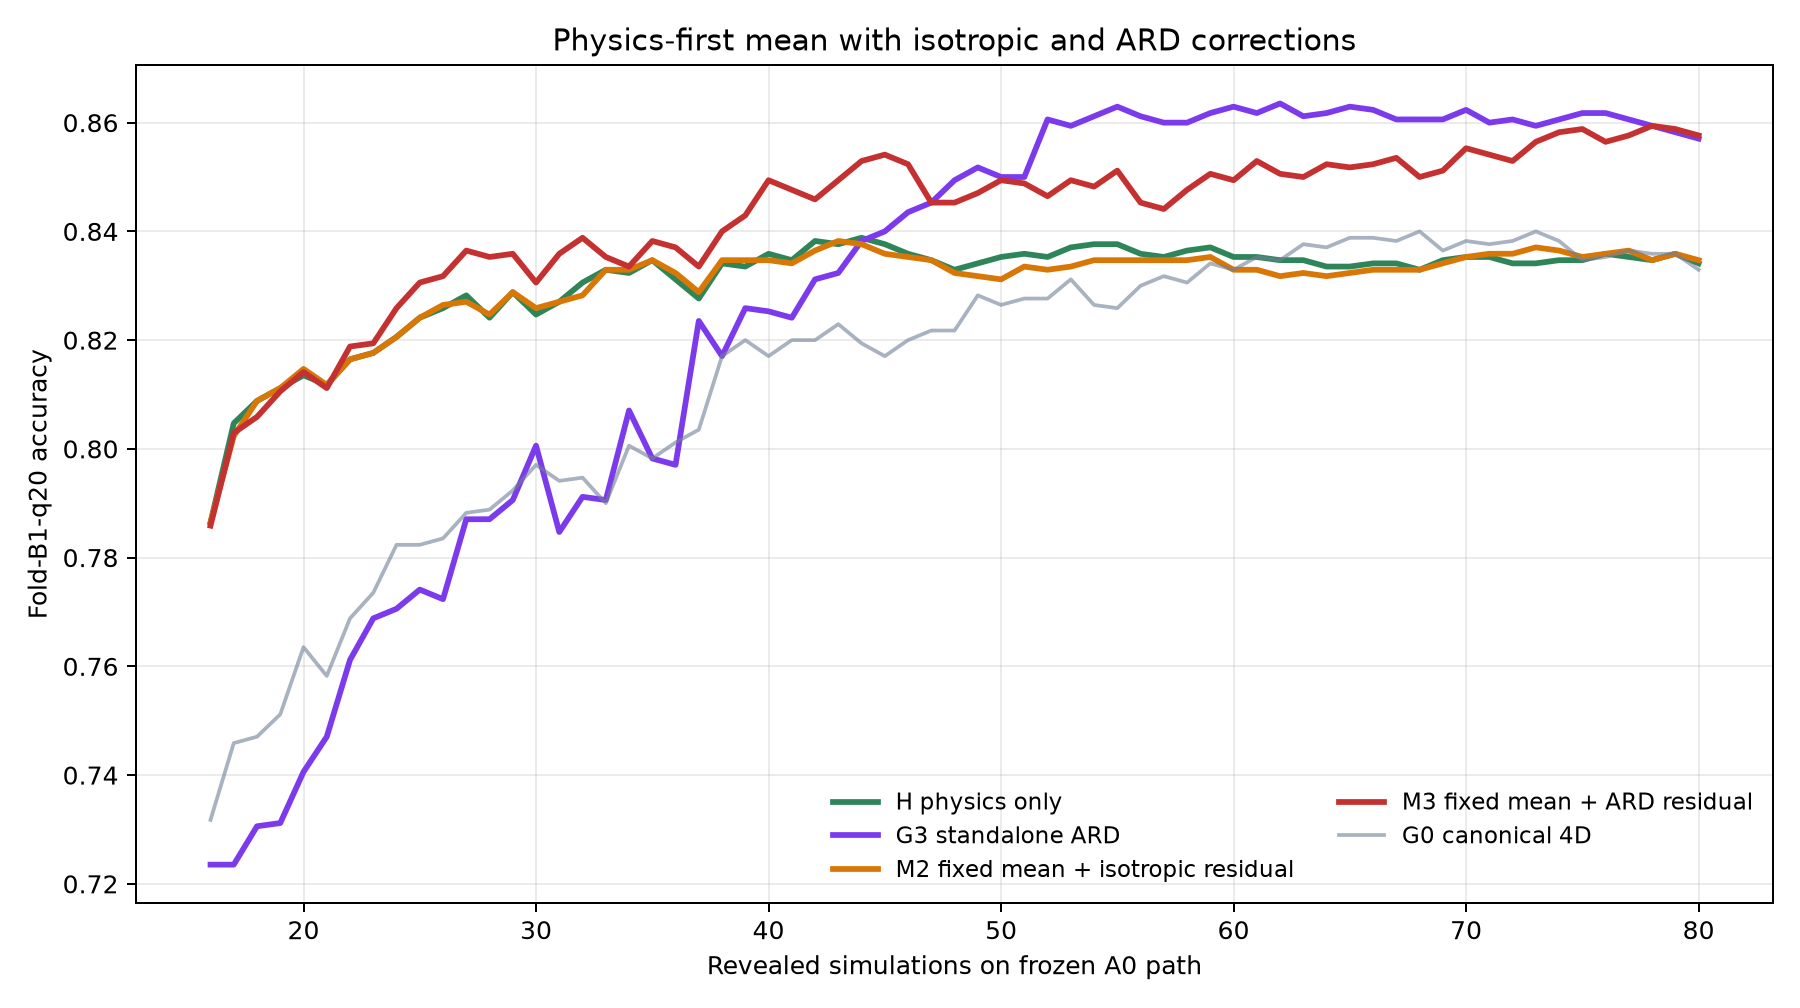

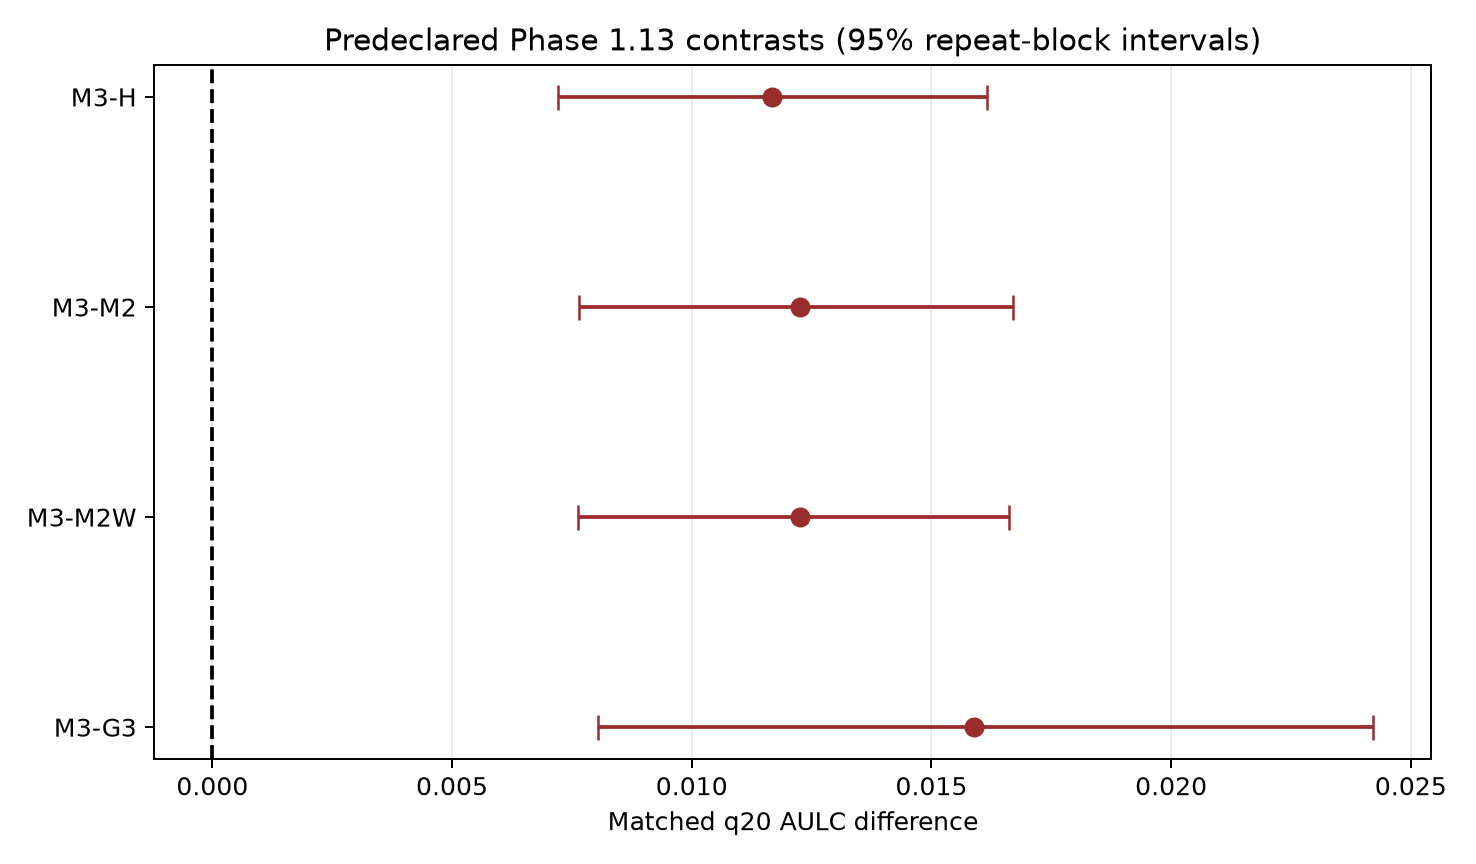

In [4]:
display(pd.read_csv(OUT/'model_summary.csv')); display(pd.read_csv(OUT/'paired_contrasts.csv').query("subset=='B1_q20'")); display(Image(filename=str(OUT/'figures'/'01_q20_learning_curves.png'))); display(Image(filename=str(OUT/'figures'/'02_q20_contrasts.png')))

## 5. Early versus late

These regions were fixed as B16-40 and B41-80 before reading the result.

,model,region,mean_AULC,ci_lower,ci_upper
0,G3,EARLY_B16_40,0.778958,0.770196,0.787991
1,G3,LATE_B41_80,0.855958,0.846387,0.864540
2,H,EARLY_B16_40,0.823162,0.817965,0.828334
3,H,LATE_B41_80,0.835407,0.830920,0.839872
4,M2,EARLY_B16_40,0.823235,0.818039,0.828285
5,M2,LATE_B41_80,0.834427,0.830377,0.838386
6,M2W,EARLY_B16_40,0.823260,0.818125,0.828456
7,M2W,LATE_B41_80,0.834412,0.830354,0.838394
8,M3,EARLY_B16_40,0.827598,0.821949,0.833358
9,M3,LATE_B41_80,0.851501,0.846214,0.856848


,contrast,region,mean_difference,ci_lower,ci_upper,positive_repeat_blocks,zero_repeat_blocks,negative_repeat_blocks,bootstrap_draws
0,M3-H,EARLY_B16_40,0.004436,0.001324,0.007917,15,0,5,10000
1,M3-G3,EARLY_B16_40,0.048640,0.040319,0.056741,20,0,0,10000
2,M3-H,LATE_B41_80,0.016094,0.009660,0.022300,18,0,2,10000
3,M3-G3,LATE_B41_80,-0.004457,-0.014744,0.006418,8,0,12,10000


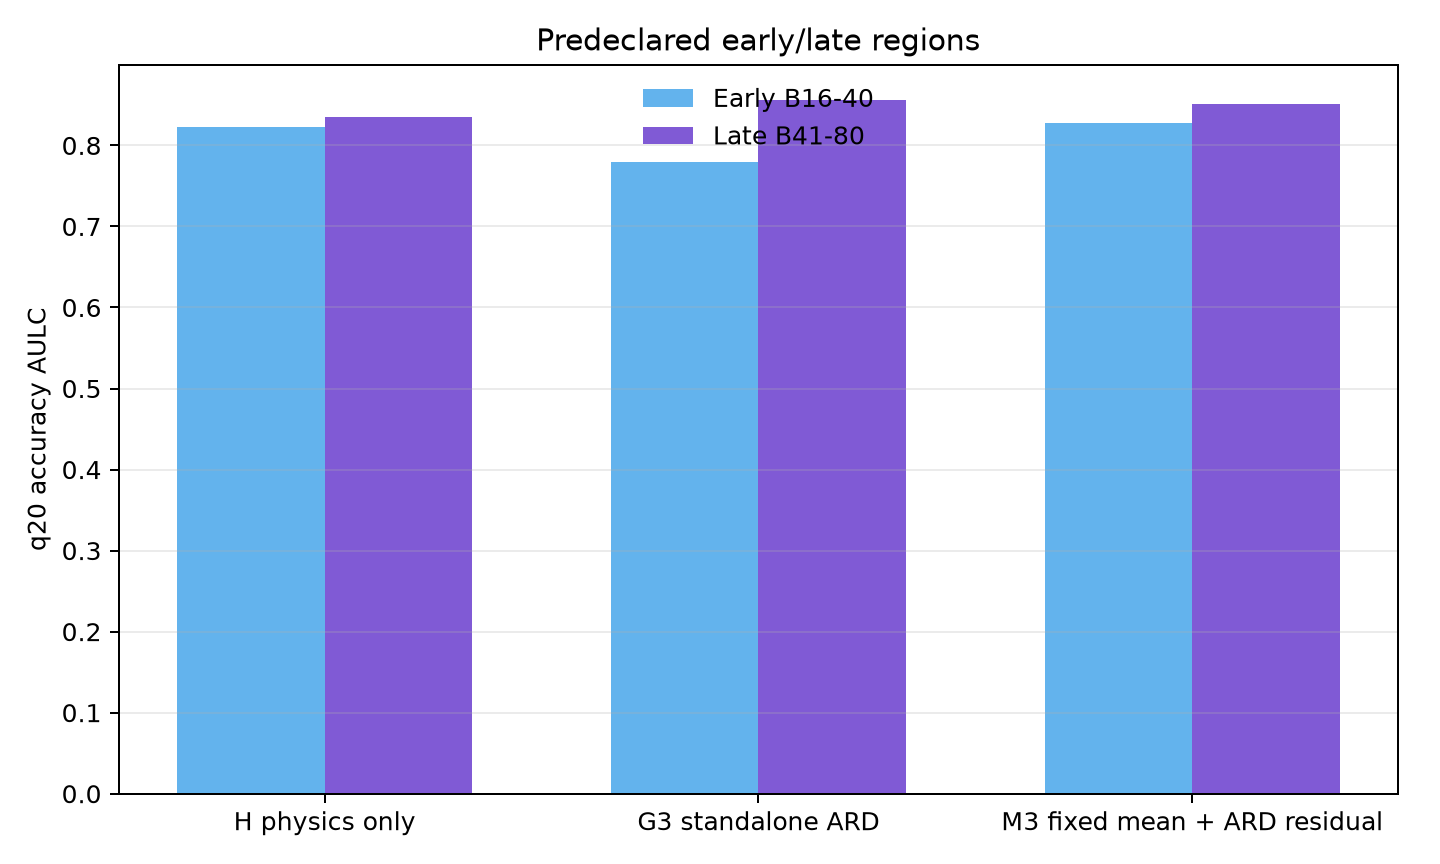

In [5]:
display(pd.read_csv(OUT/'early_late_aulc_summary.csv')); display(pd.read_csv(OUT/'early_late_contrasts.csv')); display(Image(filename=str(OUT/'figures'/'03_early_late_aulc.png')))

## 6. B16/B40/B80 confusion behavior

In [6]:
display(pd.read_csv(OUT/'checkpoint16_40_80_summary.csv')); display(pd.read_csv(OUT/'checkpoint_hard_disagreements.csv'))

,model,subset,budget,metric,mean,ci_lower,ci_upper
0,G0,B1_q20,16,accuracy,0.731765,0.714118,0.750588
1,G0,B1_q20,16,balanced_accuracy,0.686194,0.659950,0.714184
2,G0,B1_q20,16,keyhole_recall,0.497492,0.430440,0.562322
3,G0,B1_q20,16,conduction_recall,0.874897,0.850575,0.899701
4,G0,B1_q20,16,false_negative,3.280000,2.870000,3.690000
...,...,...,...,...,...,...,...
85,M3,B1_q20,80,balanced_accuracy,0.832065,0.822972,0.839952
86,M3,B1_q20,80,keyhole_recall,0.732746,0.713782,0.750183
87,M3,B1_q20,80,conduction_recall,0.931385,0.922925,0.938694
88,M3,B1_q20,80,false_negative,1.720000,1.650000,1.800000


,pair,budget,category,count,scope
0,M3_vs_H,16,same_decision,1681,100 matched outer-fold q20 predictions
1,M3_vs_H,16,different_decision,19,100 matched outer-fold q20 predictions
2,M3_vs_H,16,M3_only_correct,9,100 matched outer-fold q20 predictions
3,M3_vs_H,16,H_only_correct,10,100 matched outer-fold q20 predictions
4,M3_vs_H,16,both_correct,1327,100 matched outer-fold q20 predictions
5,M3_vs_H,16,both_wrong,354,100 matched outer-fold q20 predictions
6,M3_vs_G3,16,same_decision,1312,100 matched outer-fold q20 predictions
7,M3_vs_G3,16,different_decision,388,100 matched outer-fold q20 predictions
8,M3_vs_G3,16,M3_only_correct,247,100 matched outer-fold q20 predictions
9,M3_vs_G3,16,G3_only_correct,141,100 matched outer-fold q20 predictions


## 7. What the discrepancy actually changes

,budget,subset,metric,mean,ci_lower,ci_upper
0,16,B1_q20,physics_latent_sd,16.201555,10.776504,22.961714
1,16,B1_q20,posterior_residual_mean_sd,0.068999,0.046636,0.094062
2,16,B1_q20,final_latent_sd,16.187290,10.760347,23.126388
3,16,B1_q20,residual_log_h_spearman,0.033995,-0.038751,0.107452
4,16,B1_q20,decision_changed_fraction,0.011176,0.004118,0.019412
5,16,B1_q20,beneficial_fraction_among_changed,0.473684,0.222222,0.700000
6,16,B1_q20,harmful_fraction_among_changed,0.526316,0.300000,0.782609
7,16,full81,physics_latent_sd,28.980481,19.484051,40.824351
8,16,full81,posterior_residual_mean_sd,0.070736,0.048325,0.094822
9,16,full81,final_latent_sd,28.993424,19.558445,40.991367


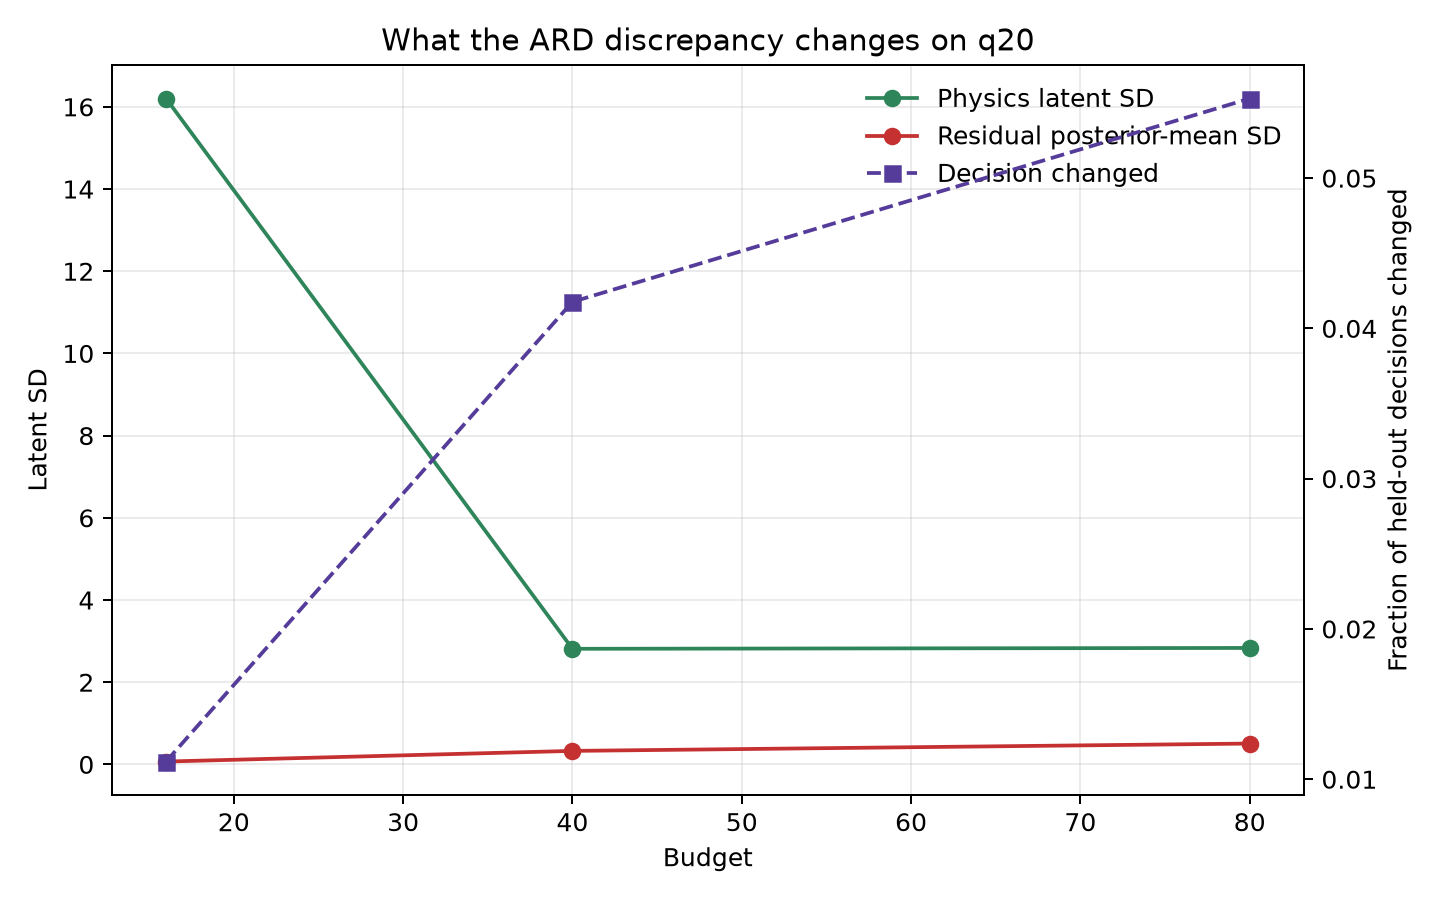

In [7]:
display(pd.read_csv(OUT/'residual_role_summary.csv')); display(Image(filename=str(OUT/'figures'/'04_residual_role.png')))

## 8. ARD and the L1000 sensitivity

Lengthscales are standardized geometry diagnostics, not causal physical importance.

,setting,budget,parameter,median,q1,q3,space
0,L100,16,l_P,0.999937,0.998905,1.503178,standardized outer-training-pool inputs
1,L100,16,l_VX,0.999439,0.614017,0.999932,standardized outer-training-pool inputs
2,L100,16,l_LS,0.999869,0.999209,1.815021,standardized outer-training-pool inputs
3,L100,16,l_ST,0.999791,0.693143,0.999992,standardized outer-training-pool inputs
4,L100,16,anisotropy_ratio,1.002529,1.000511,105.682469,standardized outer-training-pool inputs
...,...,...,...,...,...,...,...
57,L100_all_B16_80,-1,l_VX_upper_bound_hit,0.084615,NaN,NaN,fit-rate diagnostic
58,L100_all_B16_80,-1,l_LS_lower_bound_hit,0.006615,NaN,NaN,fit-rate diagnostic
59,L100_all_B16_80,-1,l_LS_upper_bound_hit,0.333538,NaN,NaN,fit-rate diagnostic
60,L100_all_B16_80,-1,l_ST_lower_bound_hit,0.008769,NaN,NaN,fit-rate diagnostic


,budget,full81_probability_MAE,full81_maximum_probability_difference,full81_hard_disagreement_count,full81_hard_disagreement_fraction,B1_q20_probability_MAE,B1_q20_maximum_probability_difference,B1_q20_hard_disagreement_count,B1_q20_hard_disagreement_fraction,L100_B1_q20_accuracy,...,L100_median_l_LS,L100_median_l_ST,L100_any_upper_bound_rate,L100_optimizer_converged_rate,L1000_median_l_P,L1000_median_l_VX,L1000_median_l_LS,L1000_median_l_ST,L1000_any_upper_bound_rate,L1000_optimizer_converged_rate
0,16,0.000018,0.004426,0,0.000000,0.000032,0.004426,0,0.000000,0.785882,...,0.999869,0.999791,0.25,0.95,0.999937,0.999439,0.999869,0.999791,0.20,0.96
1,40,0.000917,0.196590,7,0.000864,0.002288,0.174493,5,0.002941,0.849412,...,15.713550,100.000000,0.83,0.98,2.574640,0.423959,27.396549,1000.000000,0.67,0.98
2,80,0.000650,0.215521,9,0.001111,0.001947,0.215521,7,0.004118,0.857647,...,60.729306,94.432341,0.66,0.87,1.661707,0.508325,51.476328,121.136124,0.45,0.86


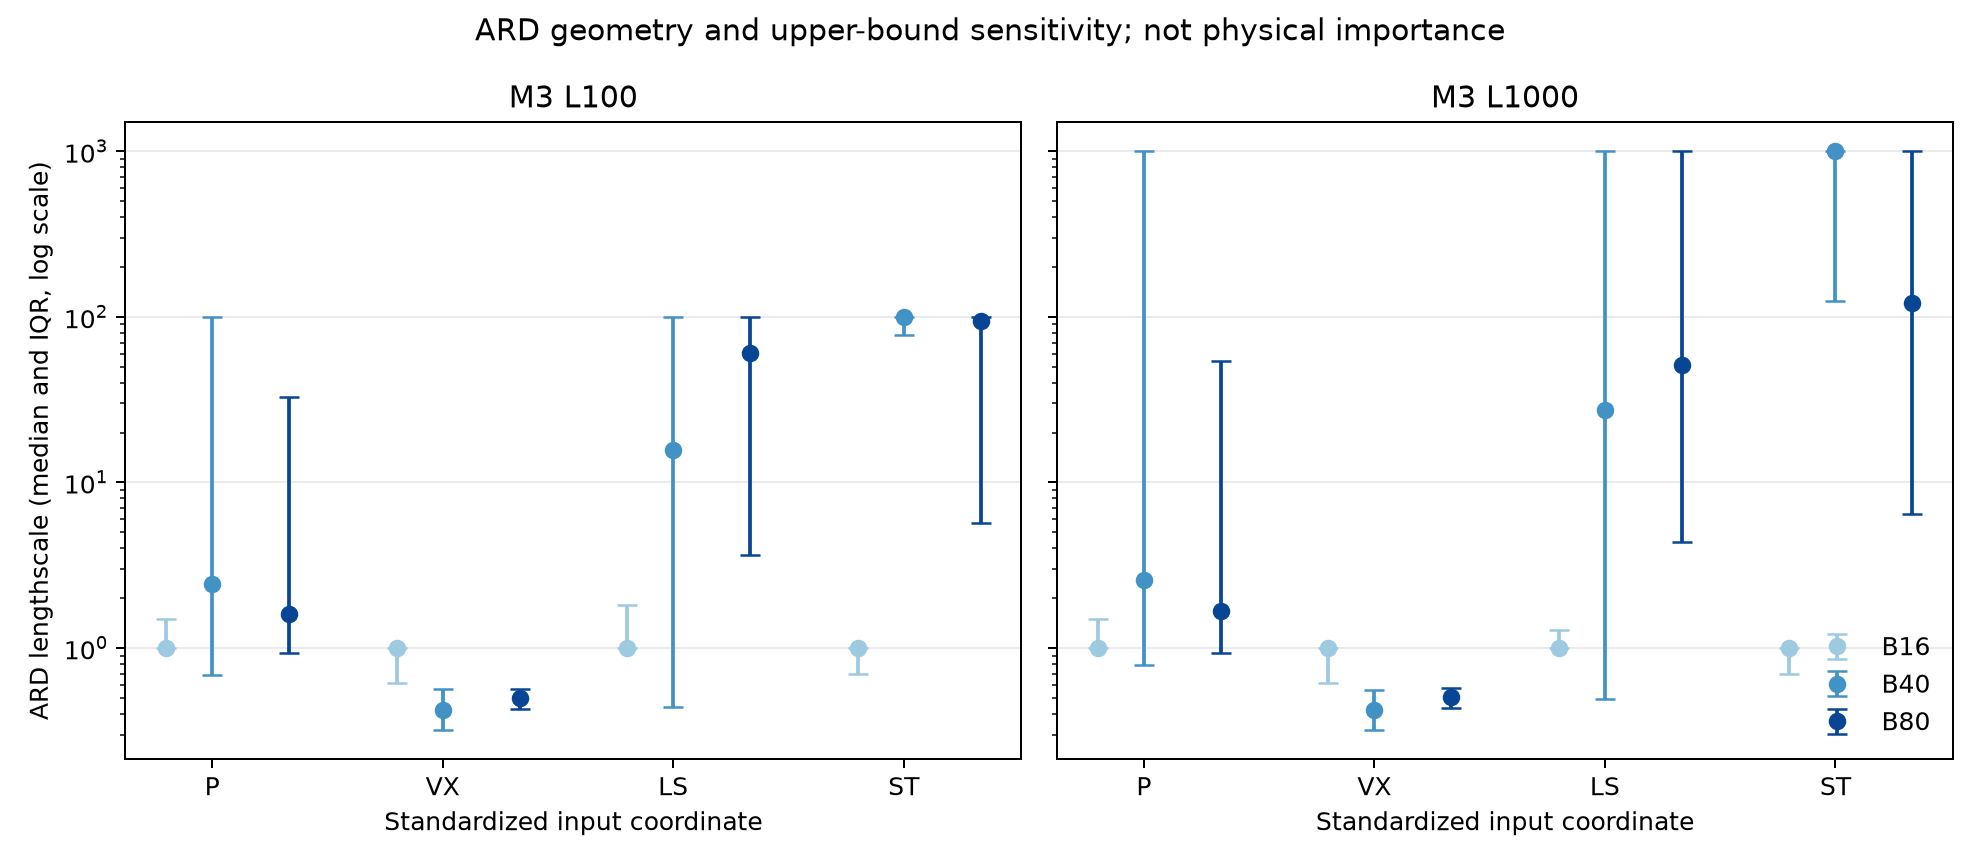

In [8]:
display(pd.read_csv(OUT/'ard_lengthscale_summary.csv')); display(pd.read_csv(OUT/'upper_bound_sensitivity.csv')); display(Image(filename=str(OUT/'figures'/'05_ard_bound_sensitivity.png')))

## 9. q30 and full81 robustness

In [9]:
display(pd.read_csv(OUT/'paired_contrasts.csv').query("subset=='B1_q30'")); display(pd.read_csv(OUT/'full81_checkpoint_summary.csv'))

,contrast,subset,mean_difference,ci_lower,ci_upper,positive_repeat_blocks,zero_repeat_blocks,negative_repeat_blocks,bootstrap_draws,predeclared_role
5,M3-H,B1_q30,0.012250,0.009153,0.015391,20,0,0,10000,secondary
6,M3-M2,B1_q30,0.012134,0.008937,0.015306,19,0,1,10000,secondary
7,M3-M2W,B1_q30,0.012122,0.008900,0.015303,19,0,1,10000,mechanistic
8,M3-G3,B1_q30,0.014172,0.007641,0.021385,16,0,4,10000,secondary
9,M3-G0,B1_q30,0.017731,0.012784,0.022191,19,0,1,10000,secondary


,model,subset,budget,metric,mean,ci_lower,ci_upper
0,G0,full81,16,roc_auc,0.979424,0.976389,0.982191
1,G0,full81,16,pr_auc,0.926310,0.915991,0.936107
2,G0,full81,16,accuracy,0.929630,0.924321,0.935185
3,G0,full81,16,balanced_accuracy,0.846125,0.827462,0.864886
4,G0,full81,16,keyhole_recall,0.715905,0.674476,0.755906
...,...,...,...,...,...,...,...
100,M3,full81,80,accuracy,0.968519,0.967407,0.969506
101,M3,full81,80,balanced_accuracy,0.932193,0.929161,0.935161
102,M3,full81,80,keyhole_recall,0.875524,0.869286,0.881857
103,M3,full81,80,conduction_recall,0.988863,0.987978,0.989629


## 10. Safe conclusion

This is a model-only comparison on one frozen simulator benchmark. It does not prove acquisition gain, orthogonality, causal importance, or external transfer.

In [10]:
display(Markdown((OUT/'SUPERVISOR_PHASE1_13_ONE_PAGE.md').read_text()))

# Supervisor Phase 1.13 â€” one page

**Decision:** HYBRID_GAIN_SUPPORTED

- q20 AULC H/G3/M2/M2W/M3: 0.8308 / 0.8266 / 0.8302 / 0.8302 / 0.8425.
- M3-H: +0.0117 [+0.0072, +0.0161].
- M3-M2: +0.0123 [+0.0076, +0.0167].
- Bound-matched anisotropy test M3-M2W: +0.0123 [+0.0076, +0.0166].
- Early M3-H: +0.0044 [+0.0013, +0.0079]; late: +0.0161 [+0.0097, +0.0223].
- B16 q20 accuracy/KH recall M3: 0.786/0.722; B80: 0.858/0.733.
- M3 residual-SD upper-bound rate: 47.9%; L100-to-L1000 max full81 probability MAE: 0.0009.
- Preferred surrogate: YES; future M3 acquisition follow-up: YES.

The test isolates anisotropy using M2W. All models saw identical A0 labels. Predictions are locally stable to the L1000 check, but amplitude and length-bound hits limit mechanistic interpretation. ARD parameters are geometry diagnostics only; no acquisition or external-validation claim is made.
